<a href="https://colab.research.google.com/github/shrustimp/ml-monitoring-system/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
# =========================
# STEP 2 - UPLOAD DATASET
# =========================

from google.colab import files

uploaded = files.upload()

Saving fitness_dataset_10.csv to fitness_dataset_10.csv


In [ ]:
# =========================
# STEP 3 - LOAD DATASET
# =========================

df = pd.read_csv('fitness_dataset_10.csv')

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   Age   BMI  Steps  Sleep           Goal    Health Activity
0   58  19.9  14149      6    Muscle Gain  Diabetes  Walking
1   24  29.5  10935      4      Endurance    Asthma   Cardio
2   19  19.6   5811      8      Endurance       NaN  Cycling
3   30  30.2  13490      8        Fitness  Diabetes     Yoga
4   55  22.7   2106      5  Stress Relief    Asthma     Yoga


In [ ]:
# =========================
# STEP 4 - DATASET INFO
# =========================

print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       9 non-null      int64  
 1   BMI       9 non-null      float64
 2   Steps     9 non-null      int64  
 3   Sleep     9 non-null      int64  
 4   Goal      9 non-null      object 
 5   Health    5 non-null      object 
 6   Activity  9 non-null      object 
dtypes: float64(1), int64(3), object(3)
memory usage: 636.0+ bytes
None


In [ ]:
# =========================
# STEP 5 - CHECK NULL VALUES
# =========================

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age         0
BMI         0
Steps       0
Sleep       0
Goal        0
Health      4
Activity    0
dtype: int64


In [ ]:
# =========================
# STEP 6 - REMOVE DUPLICATES
# =========================

df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


Dataset Shape After Removing Duplicates:
(9, 7)


In [ ]:
# =========================
# STEP 7 - HANDLE MISSING VALUES
# =========================

# Numerical Columns
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

df['Steps'] = df['Steps'].fillna(df['Steps'].mean())

df['Sleep'] = df['Sleep'].fillna(df['Sleep'].mean())

# Categorical Columns
df['Goal'] = df['Goal'].fillna(df['Goal'].mode()[0])

df['Health'] = df['Health'].fillna(df['Health'].mode()[0])

df['Activity'] = df['Activity'].fillna(df['Activity'].mode()[0])

In [ ]:
# =========================
# STEP 8 - CLEAN TEXT DATA
# =========================

df['Goal'] = df['Goal'].str.strip().str.lower()

df['Health'] = df['Health'].str.strip().str.lower()

df['Activity'] = df['Activity'].str.strip().str.lower()

In [ ]:
# =========================
# STEP 9 - REMOVE OUTLIERS
# =========================

Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['BMI'] >= lower_limit) &
    (df['BMI'] <= upper_limit)
]

print("\nDataset Shape After Outlier Removal:")
print(df.shape)


Dataset Shape After Outlier Removal:
(9, 7)


In [ ]:
# =========================
# STEP 10 - LABEL ENCODING
# =========================

# Save original categorical columns for fitting LabelEncoders
# This ensures LabelEncoders are fitted on string data, not potentially re-encoded integers
original_goal_data = df['Goal'].copy()
original_health_data = df['Health'].copy()
original_activity_data = df['Activity'].copy()

le_goal = LabelEncoder()
le_health = LabelEncoder()
le_activity = LabelEncoder()

# Fit encoders on the original string data
le_goal.fit(original_goal_data)
le_health.fit(original_health_data)
le_activity.fit(original_activity_data)

# Transform the DataFrame columns
df['Goal'] = le_goal.transform(df['Goal'])
df['Health'] = le_health.transform(df['Health'])
df['Activity'] = le_activity.transform(df['Activity'])

In [ ]:
# =========================
# STEP 11 - FEATURE SELECTION
# =========================

X = df[['Age', 'BMI', 'Steps', 'Sleep', 'Goal', 'Health']]

y = df['Activity']

In [ ]:
# =========================
# STEP 12 - TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# =========================
# STEP 13 - TRAIN MODEL
# =========================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# =========================
# STEP 14 - PREDICTIONS
# =========================

predictions = model.predict(X_test)

In [ ]:
# =========================
# STEP 15 - MODEL ACCURACY
# =========================

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:")
print(accuracy)


Model Accuracy:
0.0


In [ ]:
# =========================
# STEP 16 - CLASSIFICATION REPORT
# =========================

print("\nClassification Report:")
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           4       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



In [ ]:
# =========================
# STEP 17 - K-MEANS CLUSTERING
# =========================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

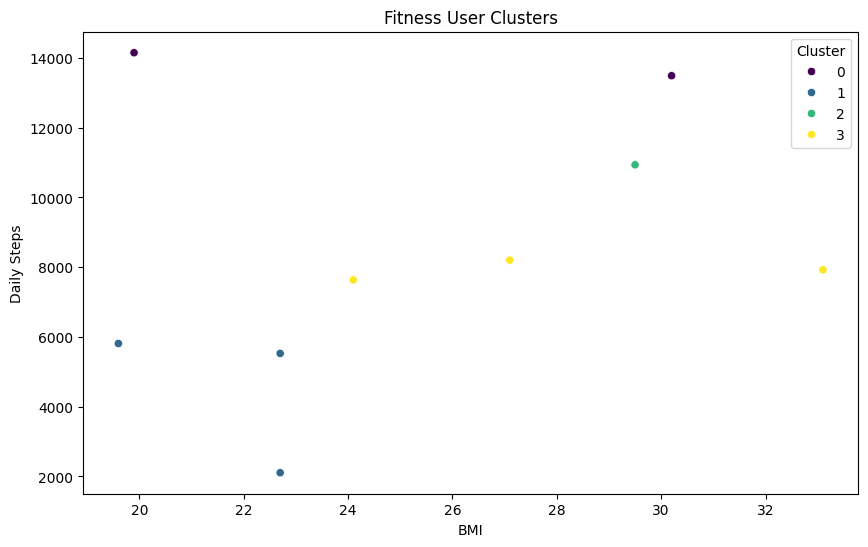

In [ ]:
# =========================
# STEP 18 - VISUALIZATION
# =========================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['BMI'],
    y=df['Steps'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Fitness User Clusters")
plt.xlabel("BMI")
plt.ylabel("Daily Steps")

plt.show()

In [ ]:
# =========================
# STEP 19 - RECOMMENDATION FUNCTION
# =========================

def recommend(age, bmi, steps, sleep, goal, health):

    # Convert input text to lowercase and strip whitespace
    goal = goal.lower().strip()
    health = health.lower().strip()

    # Encode goal and health using the fitted LabelEncoders
    # Handle unseen health labels, defaulting to a known one if necessary
    try:
        goal_encoded = le_goal.transform([goal])[0]
    except ValueError:
        print(f"Warning: Unseen goal label '{goal}'. Defaulting to '{le_goal.classes_[0]}'.")
        goal_encoded = le_goal.transform([le_goal.classes_[0]])[0]

    try:
        health_encoded = le_health.transform([health])[0]
    except ValueError:
        print(f"Warning: Unseen health label '{health}'. Defaulting to '{le_health.classes_[0]}'.")
        health_encoded = le_health.transform([le_health.classes_[0]])[0]

    input_data = pd.DataFrame([[
        age,
        bmi,
        steps,
        sleep,
        goal_encoded,
        health_encoded
    ]], columns=[
        'Age',
        'BMI',
        'Steps',
        'Sleep',
        'Goal',
        'Health'
    ])

    prediction = model.predict(input_data)

    activity = le_activity.inverse_transform(prediction)

    return activity[0]

In [ ]:
# =========================
# STEP 20 - INTERACTIVE TEST
# =========================

print("\nEnter your fitness details to get a recommendation:")

try:
    user_age = int(input("Enter your age (e.g., 25): "))
    user_bmi = float(input("Enter your BMI (e.g., 23.5): "))
    user_steps = int(input("Enter your daily steps (e.g., 8500): "))
    user_sleep = int(input("Enter your hours of sleep (e.g., 7): "))
    user_goal = input("Enter your fitness goal (e.g., flexibility, weight loss): ")
    user_health = input("Enter your health condition (e.g., none, diabetes): ")

    # Call the recommend function with user input
    recommended_activity = recommend(
        age=user_age,
        bmi=user_bmi,
        steps=user_steps,
        sleep=user_sleep,
        goal=user_goal,
        health=user_health
    )

    print("\nBased on your inputs, the recommended fitness activity is:")
    print(recommended_activity)

except ValueError:
    print("Invalid input. Please ensure you enter numbers for Age, BMI, Steps, and Sleep.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Enter your fitness details to get a recommendation:
Enter your age (e.g., 25): 35
Enter your BMI (e.g., 23.5): 56
Enter your daily steps (e.g., 8500): 6789
Enter your hours of sleep (e.g., 7): 5
Enter your fitness goal (e.g., flexibility, weight loss): weight loss
Enter your health condition (e.g., none, diabetes): none

Based on your inputs, the recommended fitness activity is:
4


In [ ]:
# =========================
# STEP 20 - TEST THE SYSTEM
# =========================

# Check encoded values
print("Goal Encoding:")
print(le_goal.classes_)

print("\nHealth Encoding:")
print(le_health.classes_)

# Example encodings:
# flexibility = 1
# none = 0

result = recommend(

    age=25,
    bmi=23,
    steps=8500,
    sleep=7,
    goal=1,
    health=0

)

print("\nRecommended Fitness Activity:")
print(result)

Goal Encoding:
[0 1 2 3 4 5]

Health Encoding:
[0 1 2]

Recommended Fitness Activity:
4


In [ ]:
# =========================
# STEP 21 - SAVE CLEANED DATASET
# =========================

df.to_csv(
    'cleaned_fitness_dataset.csv',
    index=False
)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [ ]:
# =========================
# STEP 22 - DOWNLOAD CLEANED DATASET
# =========================

files.download('cleaned_fitness_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>